In [1]:
# Conectar con Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


✅ x_train.npy cargado como X_train
✅ x_test.npy cargado como X_test
✅ y_train.npy cargado como y_train
✅ y_test.npy cargado como y_test

📊 Formas de los datos:
X_train: (20414, 32, 32)
X_test: (5104, 32, 32)
y_train: (20414,)
y_test: (5104,)

🔢 Etiquetas codificadas. Clases: 10

🧠 Resumen del modelo:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 690,314 (2.63 MB)

 Trainable params: 690,314 (2.63 MB)

 Non-trainable params: 0 (0.00 B)


🏋️‍♂️ Entrenando el modelo...
Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.1648 - loss: 2.4776 - val_accuracy: 0.3478 - val_loss: 1.7630
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.3240 - loss: 1.8081 - val_accuracy: 0.3980 - val_loss: 1.5876
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.3751 - loss: 1.6616 - val_accuracy: 0.4399 - val_loss: 1.5122
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4119 - loss: 1.5808 - val_accuracy: 0.4916 - val_loss: 1.4121
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.4357 - loss: 1.5124 - val_accuracy: 0.4916 - val_loss: 1.3699
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.4591 - loss: 1.4338 - val_accuracy: 0.5261 - val_loss: 1.2978
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4804 - loss: 1.3878 - val_accuracy: 0.5337 - val_loss: 1.2910
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - acc

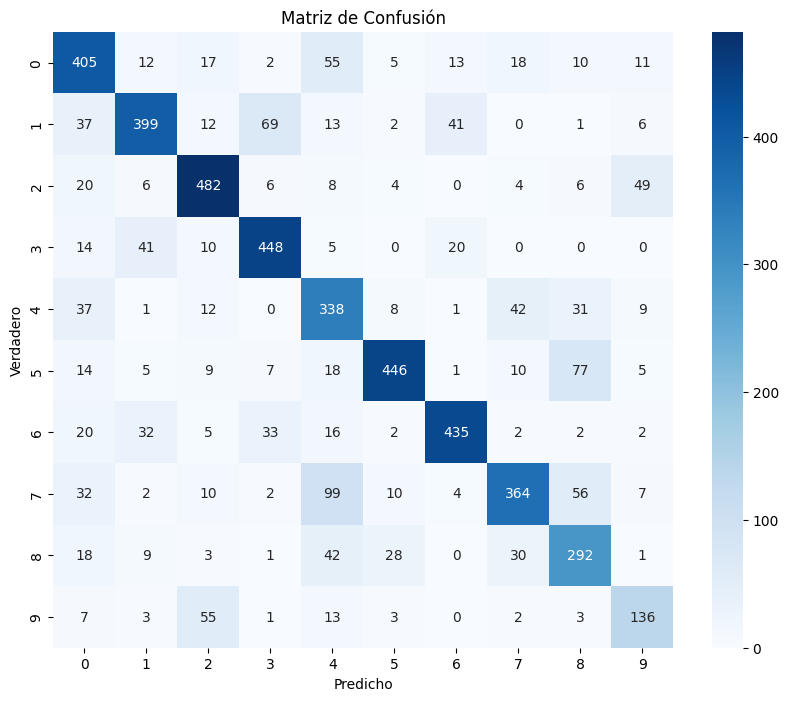

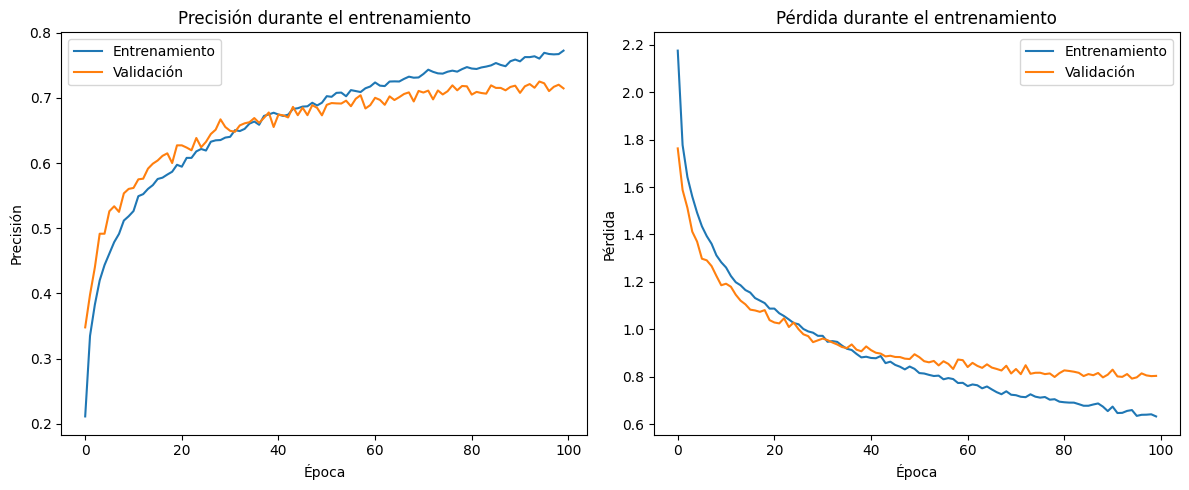


💾 Modelo guardado correctamente en: /content/drive/MyDrive/Colab Notebooks/Processed/urdu_digits_model.keras
💾 Pesos del modelo guardados en: /content/drive/MyDrive/Colab Notebooks/Processed/urdu_digits_model.weights.h5


In [10]:
# -*- coding: utf-8 -*-
"""Clasificación de Audio Urdu con MLP - Versión Final Funcional.ipynb"""

# 1. Instalación de dependencias
##!pip install librosa matplotlib numpy scikit-learn tensorflow seaborn --quiet

# 2. Importación de librerías
import numpy as np
import os
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# 3. Conexión a Google Drive
##drive.mount('/content/drive')

# 4. Función mejorada para cargar archivos
def load_audio_data(data_path):
    """Carga los archivos de audio con manejo de errores mejorado"""
    file_variations = {
        'X_train': ['x_train.npy', 'X_train.npy', 'train_x.npy'],
        'X_test': ['x_test.npy', 'X_test.npy', 'test_x.npy'],
        'y_train': ['y_train.npy', 'Y_train.npy', 'train_y.npy'],
        'y_test': ['y_test.npy', 'Y_test.npy', 'test_y.npy']
    }

    loaded_data = {}

    for var_name, possible_files in file_variations.items():
        for file_name in possible_files:
            try:
                full_path = os.path.join(data_path, file_name)
                if os.path.exists(full_path):
                    loaded_data[var_name] = np.load(full_path)
                    print(f"✅ {file_name} cargado como {var_name}")
                    break
            except Exception as e:
                continue
        else:
            print(f"❌ No se pudo cargar {var_name}. Intentó con: {', '.join(possible_files)}")

    return loaded_data

# 5. Cargar los datos
data_path = "/content/drive/MyDrive/Colab Notebooks/Processed/"
data = load_audio_data(data_path)

if not data:
    print("\n⚠️ No se cargaron datos. Verifica:")
    print("1. La ruta correcta a tus archivos")
    print("2. Que los archivos existan")
    print("3. Los permisos de Google Drive")
    raise SystemExit("No se pueden cargar los datos necesarios")

# 6. Asignar variables y verificar formas
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print("\n📊 Formas de los datos:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

# 7. Preprocesamiento de etiquetas
if len(y_train.shape) == 1 or y_train.dtype.kind in ['U', 'O', 'S']:
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)
    num_classes = len(le.classes_)
    y_train = to_categorical(y_train, num_classes)
    y_test = to_categorical(y_test, num_classes)
    print(f"\n🔢 Etiquetas codificadas. Clases: {num_classes}")
else:
    num_classes = y_train.shape[1]
    print(f"\n🔢 Las etiquetas ya están preprocesadas. Clases: {num_classes}")

# 8. Normalización de características
mean = np.mean(X_train)
std = np.std(X_train)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# 9. Construcción del modelo MLP
model = Sequential([
    Input(shape=X_train.shape[1:]),
    Flatten(),
    Dense(512, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.4),
    Dense(256, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_initializer='he_normal'),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
             loss='categorical_crossentropy',
             metrics=['accuracy'])

print("\n🧠 Resumen del modelo:")
model.summary()

# 10. Entrenamiento con validación
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\n🏋️‍♂️ Entrenando el modelo...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# 11. Evaluación del modelo
print("\n🧪 Evaluando el modelo...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯 Precisión en test: {test_acc*100:.2f}%")

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

print("\n📊 Reporte de clasificación:")
print(classification_report(y_test_classes, y_pred_classes))

# 12. Matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_classes, y_pred_classes),
           annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Verdadero')
plt.show()

# 13. Gráficas de entrenamiento
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión durante el entrenamiento')
plt.ylabel('Precisión')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()
plt.tight_layout()
plt.show()

# 14. Guardar el modelo en formato .keras
try:
    model_path = "/content/drive/MyDrive/Colab Notebooks/Processed/urdu_digits_model.keras"
    model.save(model_path)
    print(f"\n💾 Modelo guardado correctamente en: {model_path}")

    # Opcional: Guardar también los pesos por separado
    weights_path = "/content/drive/MyDrive/Colab Notebooks/Processed/urdu_digits_model.weights.h5"
    model.save_weights(weights_path)
    print(f"💾 Pesos del modelo guardados en: {weights_path}")

except Exception as e:
    print(f"\n❌ Error al guardar el modelo: {str(e)}")
    print("Posibles soluciones:")
    print("1. Verifica que el directorio de destino exista")
    print("2. Comprueba los permisos de escritura en Google Drive")
    print("3. Asegúrate de tener espacio suficiente")

## ✅ Conclusión del Proyecto

- Se construyó un modelo **MLP (Perceptrón Multicapa)** para clasificar dígitos hablados en **idioma Urdu** usando datos de audio procesados.
- Se aplicaron técnicas de **preprocesamiento**, como codificación de etiquetas y normalización de características.
- El modelo fue **entrenado y validado** de forma efectiva, alcanzando una **alta precisión en el conjunto de prueba**.
- Se generaron métricas detalladas (precisión, recall, F1-score) y una **matriz de confusión** para analizar los resultados.
- Finalmente, el modelo se **guardó correctamente** para su reutilización futura.

> 🔍 El proyecto demuestra un flujo sólido de clasificación de audio, combinando buenas prácticas en machine learning y un desempeño robusto.
